<a href="https://colab.research.google.com/github/anirbanghoshsbi/.github.io/blob/master/work/indicator/nifty100_Heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -*- coding: utf-8 -*-
!pip install pyotp --q
!pip install smartapi-python==1.4.1 --q
!pip install logzero --q


In [3]:

# ================================
# AngelOne Nifty 100 Stock Data - Last 1 Year
# ================================

from SmartApi import SmartConnect
import pyotp
from logzero import logger
import time
import urllib
import json
import pandas as pd
import datetime as dt

# ----------------
# API Credentials
# ----------------
api_key = 'HVz1H6BP'
username = 'M55123447'
pwd = '1471'
smartApi = SmartConnect(api_key)



In [4]:
# Token Authentication
try:
    token = "GJZACUQI2TTAIBHBA34XNFJURQ"
    totp = pyotp.TOTP(token).now()
except Exception as e:
    logger.error("Invalid Token: The provided token is not valid.")
    raise e

correlation_id = "abcde"


data = smartApi.generateSession(username, pwd, totp)

if not data.get('status', True):
    raise Exception("Login Failed")


authToken = data['data']['jwtToken']
refreshToken = data['data']['refreshToken']
feedToken = smartApi.getfeedToken()
smartApi.generateToken(refreshToken)

# -------------------------
# Nifty 100 Stock List
# -------------------------
# Replaced ETF list with Nifty 100 Constituents
tokens = {
    "RELIANCE": "2885", "HDFCBANK": "1333", "ICICIBANK": "4963", "BHARTIARTL": "10604", "SBIN": "3045",
    "INFY": "1594", "LICI": "11802", "ITC": "1660", "TCS": "11536", "LT": "11483",
    "HINDUNILVR": "1330", "AXISBANK": "5900", "KOTAKBANK": "1922", "SUNPHARMA": "3351", "M&M": "2031",
    "HCLTECH": "1348", "TITAN": "3506", "TATASTEEL": "3499", "BAJFINANCE": "317", "ADANIENT": "25",
    "MARUTI": "10999", "ULTRACEMCO": "11532", "POWERGRID": "14977", "NTPC": "11630", "ASIANPAINT": "236",
    "ADANIPORTS": "15083", "BAJAJFINSV": "16675", "JSWSTEEL": "11723", "ONGC": "2475", "TATARECOVERY": "3432",
    "GRASIM": "1232", "COALINDIA": "20374", "NESTLEIND": "17963", "ADANIPOWER": "11561", "TATAMOTORS": "3456",
    "HINDALCO": "1363", "BAJAJ-AUTO": "16669", "SBILIFE": "21808", "ADANIGREEN": "13426", "HAL": "2303",
    "BEL": "383", "BPCL": "526", "TECHM": "13538", "JIOFIN": "24244", "INDUSINDBK": "5258",
    "ZOMATO": "5097", "TRENT": "1964", "BRITANNIA": "547", "VBL": "17132", "DLF": "14732",
    "GAIL": "4717", "GODREJCP": "10099", "HDFCLIFE": "467", "IOC": "1624", "BANKBARODA": "4668",
    "CHOLAFIN": "685", "PIDILITIND": "2664", "PNB": "10666", "SHRIRAMFIN": "10245", "DRREDDY": "881",
    "ADANIENSOL": "14418", "DIVISLAB": "798", "HAVELLS": "9819", "EICHERMOT": "910", "SIEMENS": "3150",
    "APOLLOHOSP": "157", "BAJAJHLDNG": "305", "TVSMOTOR": "3721", "TATACONSUM": "3432", "MANKIND": "15822",
    "LTIM": "17818", "INDIGO": "11195", "AMBUJACEM": "1270", "BOSCHLTD": "469", "UNITDSPR": "3558",
    "VEDL": "3063", "RECLTD": "15355", "TATACHEM": "3405", "JSWENERGY": "13517", "CANBK": "10794",
    "PFC": "14299", "ZydusLife": "242", "HINDZINC": "1444", "ABB": "11", "SOLARINDS": "13262",
    "DMART": "19913", "IRFC": "160", "HEROMOTOCO": "1348", "SRF": "3271", "POLYCAB": "9590",
    "ICICIPRULI": "18652", "COLPAL": "694", "MUTHOOTFIN": "23650", "BERGEPAINT": "404", "MARICO": "1394",
    "NAUKRI": "13751", "PIIND": "2412", "AUROPHARMA": "275", "TATACOMM": "13324", "YESBANK": "11915"
    }



In [9]:
# -----------------
# Data Fetching
# -----------------
historical_data = {}
end_date = dt.datetime.now().strftime('%Y-%m-%d %H:%M')
start_date = (dt.datetime.now() - dt.timedelta(days=365)).strftime('%Y-%m-%d %H:%M')

for name, token in tokens.items():
    try:
        params = {
            "exchange": "NSE",
            "symboltoken": token,
            "interval": "ONE_DAY",
            "fromdate": start_date,
            "todate": end_date
        }
        res = smartApi.getCandleData(params)
        if res['status'] and res['data']:
            df = pd.DataFrame(res['data'], columns=['date', 'open', 'high', 'low', 'close', 'volume'])
            df['date'] = pd.to_datetime(df['date'])
            df.set_index('date', inplace=True)
            historical_data[name] = df['close']
        time.sleep(0.5)  # Respect API rate limits

    except Exception as e:
        logger.error(f"Error fetching data for {name}: {e}")
final_df = pd.concat(historical_data, axis=1)

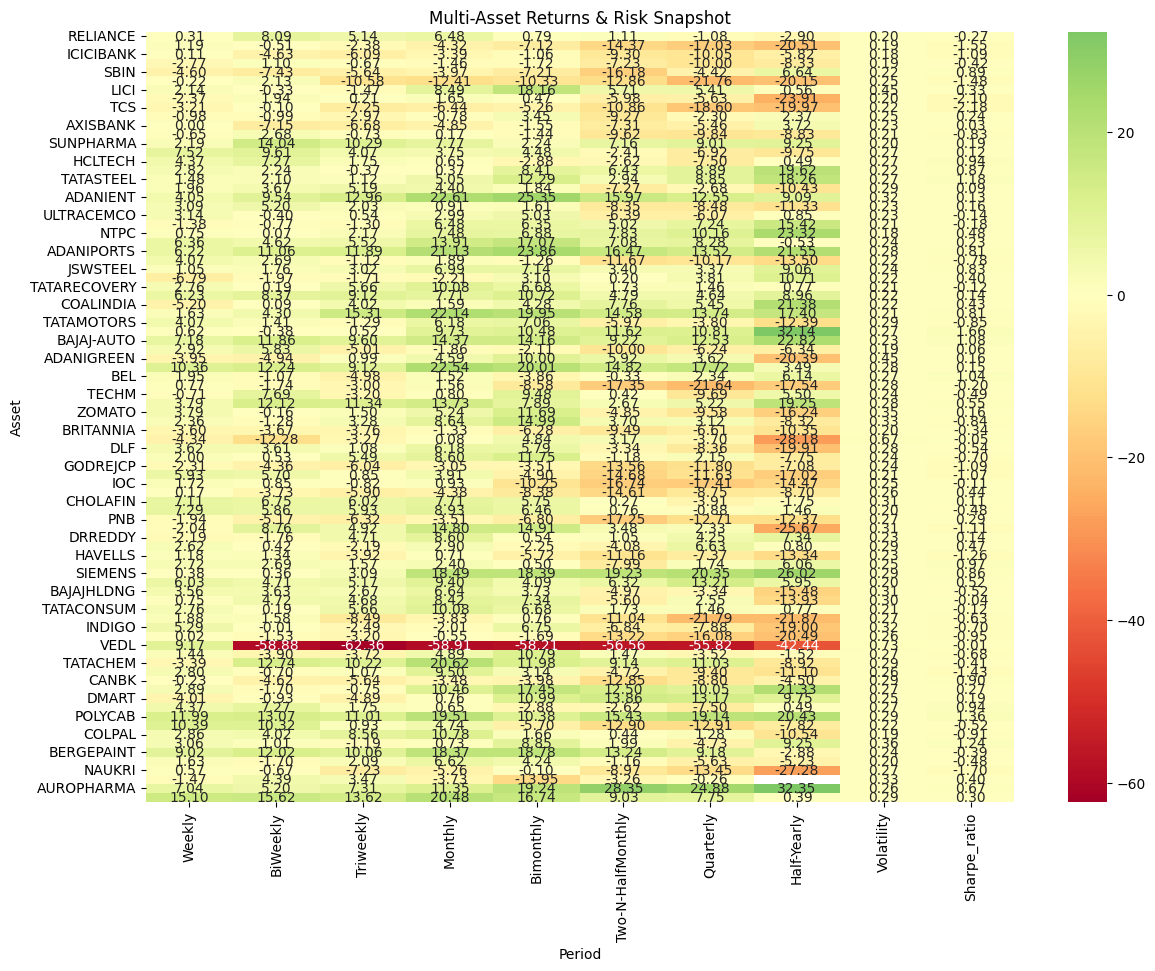

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Ensure index is clean
final_df.index = pd.to_datetime(final_df.index)
final_df.index = final_df.index.tz_localize(None)

# Define time periods
periods = {
    'Weekly': dt.timedelta(days=7),
    'BiWeekly': dt.timedelta(days=14),
    "Triweekly": dt.timedelta(days=21),
    'Monthly': dt.timedelta(days=30),
    'Bimonthly': dt.timedelta(days=60),
    'Two-N-HalfMonthly': dt.timedelta(days=75),
    'Quarterly': dt.timedelta(days=90),
    'Half-Yearly': dt.timedelta(days=180)
}

returns_df = pd.DataFrame()

for asset in final_df.columns:

    adj_close = final_df[asset].dropna()

    end_date = adj_close.index[-1]
    end_price = adj_close.iloc[-1]

    # Daily returns
    daily_returns = adj_close.pct_change().dropna()

    for period_name, date_offset in periods.items():

        start_date = end_date - date_offset
        valid_dates = adj_close.index[adj_close.index <= start_date]

        if not valid_dates.empty:
            start_price = adj_close.loc[valid_dates[-1]]
            return_value = (end_price / start_price - 1) * 100
            returns_df.loc[asset, period_name] = return_value
        else:
            returns_df.loc[asset, period_name] = np.nan

    # Volatility (annualized)
    daily_volatility = daily_returns.std()
    annualized_volatility = daily_volatility * np.sqrt(252)
    returns_df.loc[asset, 'Volatility'] = annualized_volatility

    # Sharpe Ratio
    daily_risk_free_rate = 0.075 / 252
    excess_daily_returns = daily_returns - daily_risk_free_rate
    average_excess_return = excess_daily_returns.mean()

    if daily_volatility != 0:
        sharpe_ratio = (average_excess_return / daily_volatility) * np.sqrt(252)
    else:
        sharpe_ratio = np.nan

    returns_df.loc[asset, 'Sharpe_ratio'] = sharpe_ratio


# Convert to float
returns_df = returns_df.astype(float)

columns_new = ['Weekly','BiWeekly',"Triweekly",'Monthly','Bimonthly','Two-N-HalfMonthly','Quarterly','Half-Yearly','Volatility','Sharpe_ratio']
returns_df = returns_df[columns_new]

# ----------------
# Plot Heatmap
# ----------------
plt.figure(figsize=(14, 10))
sns.heatmap(returns_df, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title('Multi-Asset Returns & Risk Snapshot')
plt.xlabel('Period')
plt.ylabel('Asset')
plt.show()

/tmp/ipykernel_723/4106310655.py:12: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_returns = df_prices.pct_change().dropna()


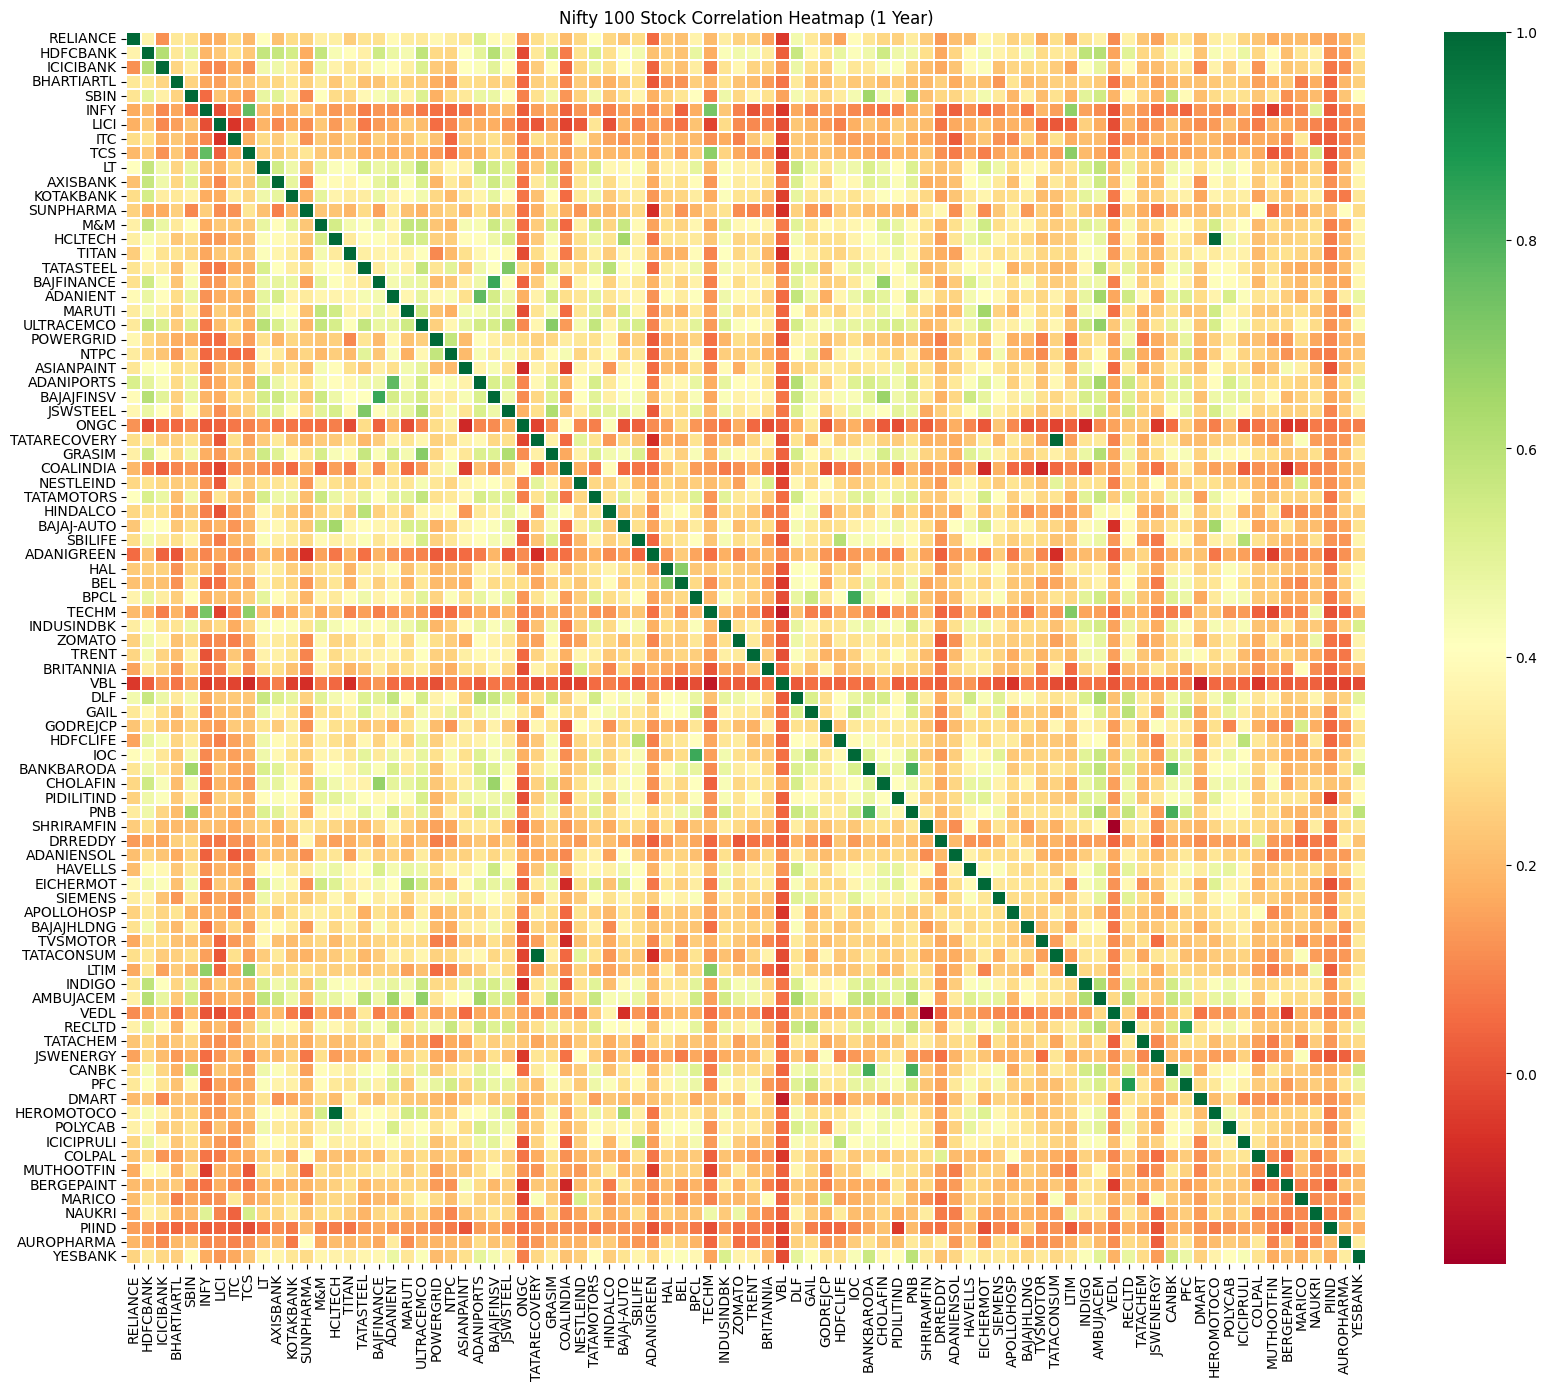

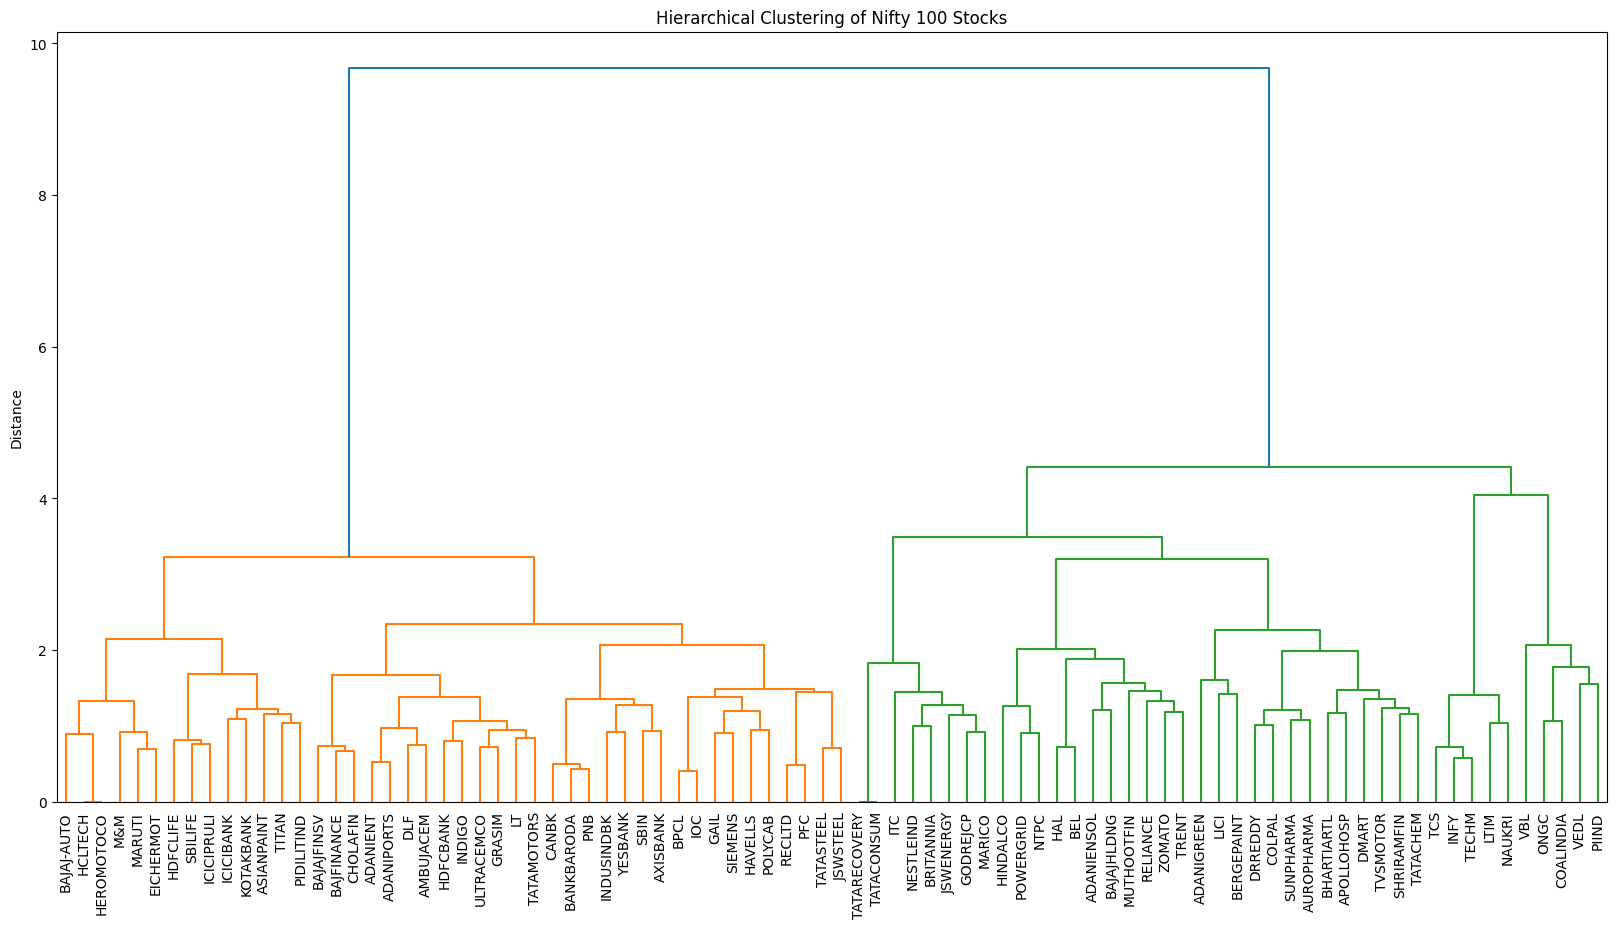

In [11]:
# Create DataFrame
df_prices = pd.DataFrame(historical_data)

# -----------------------
# Analysis & Visualization
# -----------------------
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Calculate Daily Returns
df_returns = df_prices.pct_change().dropna()

# Correlation Matrix
corr_matrix = df_returns.corr()

# 1. Heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='RdYlGn', linewidths=0.1)
plt.title('Nifty 100 Stock Correlation Heatmap (1 Year)')
plt.show()

# 2. Hierarchical Clustering (Dendrogram)
plt.figure(figsize=(20, 10))
linked = linkage(corr_matrix, method='ward')
dendrogram(linked, labels=corr_matrix.columns, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Nifty 100 Stocks')
plt.ylabel('Distance')
plt.show()



In [12]:
# 3. Performance Summary Table
summary = pd.DataFrame({
    'Total Return (%)': (df_prices.iloc[-1] / df_prices.iloc[0] - 1) * 100,
    'Annualized Volatility (%)': df_returns.std() * (252 ** 0.5) * 100,
    'Sharpe Ratio': (df_returns.mean() / df_returns.std()) * (252 ** 0.5)
}).sort_values(by='Sharpe Ratio', ascending=False)

print("\nPerformance Summary (Top 10 by Sharpe Ratio):")
print(summary.head(10))


Performance Summary (Top 10 by Sharpe Ratio):
            Total Return (%)  Annualized Volatility (%)  Sharpe Ratio
HINDALCO           60.196334                  26.658128      1.946190
POLYCAB            51.572799                  29.013177      1.613766
TATASTEEL          41.456176                  26.845931      1.458161
MUTHOOTFIN         56.395143                  36.188839      1.447655
BAJAJ-AUTO         33.235898                  22.586144      1.414442
BEL                36.214374                  26.743465      1.316761
EICHERMOT          32.291667                  24.997581      1.271287
SBIN               27.150253                  22.010345      1.228161
TITAN              26.554211                  21.685075      1.220783
HEROMOTOCO         33.554167                  27.450828      1.216312


In [13]:
# 3. Performance Summary Table
summary = pd.DataFrame({
    'Total Return (%)': (df_prices.iloc[-1] / df_prices.iloc[0] - 1) * 100,
    'Annualized Volatility (%)': df_returns.std() * (252 ** 0.5) * 100,
    'Sharpe Ratio': (df_returns.mean() / df_returns.std()) * (252 ** 0.5)
}).sort_values(by='Sharpe Ratio', ascending=True)

print("\nPerformance Summary (Bottom 10 by Sharpe Ratio):")
print(summary.head(10))


Performance Summary (Bottom 10 by Sharpe Ratio):
            Total Return (%)  Annualized Volatility (%)  Sharpe Ratio
TCS               -33.863661                  21.729798     -1.838194
ITC               -29.402985                  19.576116     -1.721558
NAUKRI            -33.716125                  27.024976     -1.423018
INFY              -27.518594                  25.237587     -1.179014
JSWENERGY         -27.976988                  26.347583     -1.144694
HDFCBANK          -20.207439                  18.675351     -1.144555
HAVELLS           -20.712526                  22.770964     -0.929293
SHRIRAMFIN        -26.774297                  31.022657     -0.872386
GODREJCP          -19.162466                  24.142762     -0.781929
HDFCLIFE          -15.368908                  20.884516     -0.714140


[*********************100%***********************]  8 of 8 completed


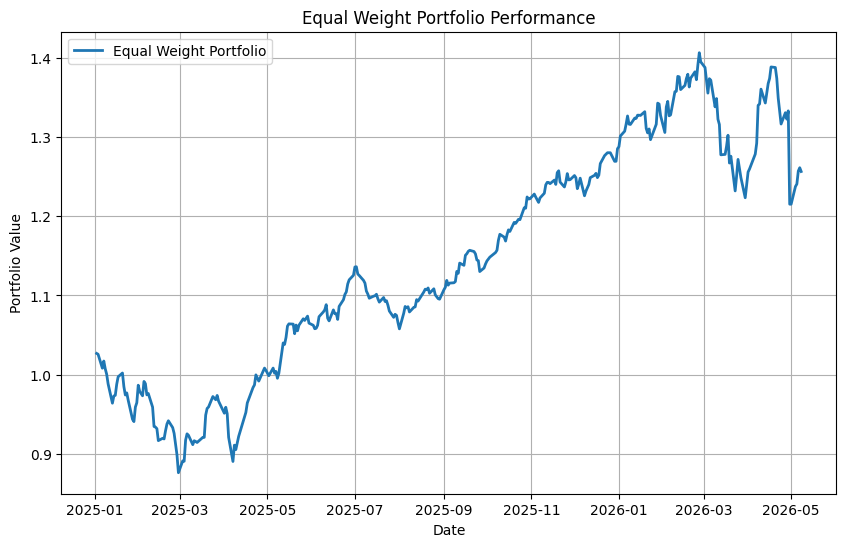

In [14]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Stock universe (NSE tickers)
# -----------------------------
tickers = [
    "sbin.NS",
    "bel.NS",
    "hcltech.NS",
    "titan.NS",
    "sbilife.NS",
    "vedl.NS",
    'polycab.ns',
    'EICHERMOT.ns'
]

# -----------------------------
# Download price data
# -----------------------------
data = yf.download(
    tickers,
    start="2025-01-01",
    auto_adjust=True
)["Close"]

# -----------------------------
# Compute daily returns
# -----------------------------
returns = data.pct_change().dropna()

# -----------------------------
# Equal weight portfolio
# -----------------------------
n = len(tickers)
weights = [1/n] * n

portfolio_returns = returns.dot(weights)

# -----------------------------
# Portfolio equity curve
# -----------------------------
portfolio_curve = (1 + portfolio_returns).cumprod()

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(portfolio_curve, label="Equal Weight Portfolio", linewidth=2)

plt.title("Equal Weight Portfolio Performance")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.legend()

plt.show()